In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
df = pd.read_csv('../Datasets/height_weight.csv')
df.head()  

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [4]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


Text(0, 0.5, 'Height')

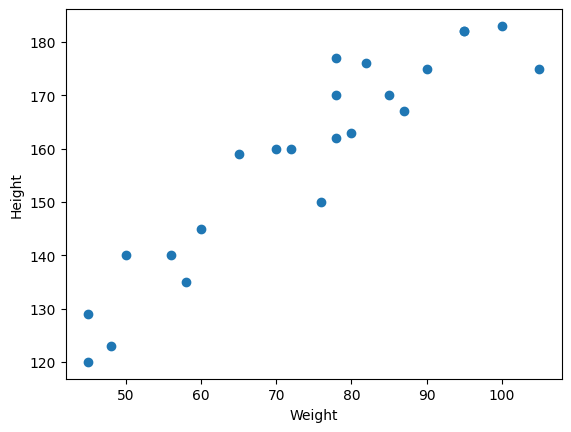

In [11]:
## scatter plot
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height') ## based on this we can see that these are positively correlated

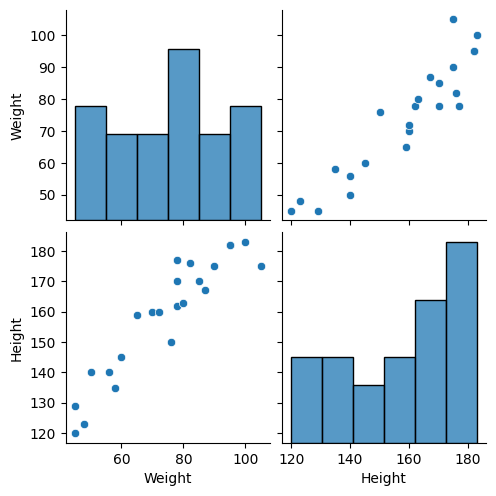

In [9]:
sns.pairplot(df)

In [10]:
## check for null values
df.isna().sum()

Weight    0
Height    0
dtype: int64

In [12]:
## divide features in independent and dependent features
X = df.drop('Height', axis=1)
y = df['Height']

In [14]:
X.shape, y.shape ## Independent feature should be a dataframe or a 2D array

((23, 1), (23,))

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [17]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((16, 1), (7, 1), (16,), (7,))

In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
reg = LinearRegression()

In [20]:
reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
y_preds = reg.predict(X_test)

In [22]:
y_preds

array([162.55745791, 162.55745791, 128.70154204, 179.99838426,
       149.22027893, 190.25775271, 142.03872102])

In [ ]:
from sklearn.metrics import r2_score

scr = r2_score(y_preds, y_test)
print(scr) ## here the accuracy is coming 73% which can be improved if we use Scaling of independent features

0.7369789043073502


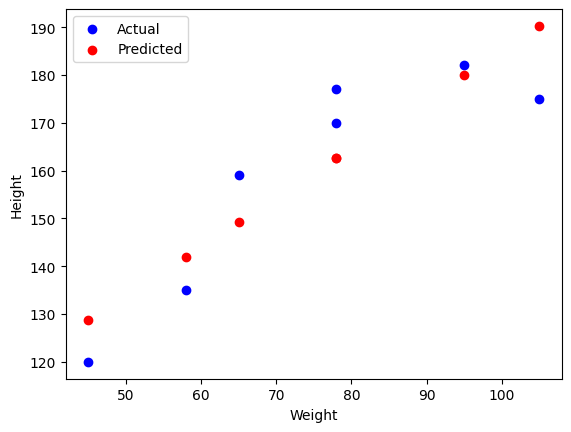

In [29]:
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.scatter(X_test, y_preds, color='red', label='Predicted')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.legend()
